In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import simpy
import warnings
warnings.filterwarnings('ignore')

# تنظیمات نمایش
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)

# تنظیمات فارسی (در صورت نیاز)
# plt.rcParams['font.family'] = 'DejaVu Sans'

print("="*80)
print("شروع پروژه تحلیل و پیش‌بینی زمان انتظار در صف بانک")
print("="*80)

# ==============================
# مرحله 1: بارگذاری داده‌ها
# ==============================
print("\n" + "="*80)
print("مرحله 1: بارگذاری داده‌ها از فایل Excel")
print("="*80)


file_path = r'C:\Users\admin\Downloads\Bank_Queue_OneMonth_Results.xlsx'
df_raw = pd.read_excel(file_path)



print(f"تعداد کل رکوردهای اولیه: {len(df_raw):,}")
print(f"ستون‌های موجود: {list(df_raw.columns)}")

# نمایش ۵ رکورد اول
print("\nنمونه داده‌های اولیه (۵ رکورد اول):")
print(df_raw.head())

# تبدیل ستون‌های زمانی به فرمت datetime
df_raw['Arrival_Time'] = pd.to_datetime(df_raw['Arrival_Time'])
df_raw['Service_Start_Time'] = pd.to_datetime(df_raw['Service_Start_Time'])
df_raw['Service_End_Time'] = pd.to_datetime(df_raw['Service_End_Time'])


# نمایش اطلاعات کلی
print("\nاطلاعات کلی داده‌ها:")
print(df_raw.info())

# ==============================
# مرحله 2: پیش‌پردازش و پاک‌سازی داده‌ها
# ==============================
print("\n" + "="*80)
print("مرحله 2: پیش‌پردازش و پاک‌سازی داده‌ها")
print("="*80)

# 2.1. حذف رکوردهای تکراری
print("\n2.1. حذف رکوردهای تکراری...")
initial_count = len(df_raw)
df = df_raw.drop_duplicates()
duplicates_removed = initial_count - len(df)
print(f"   تعداد رکوردهای تکراری حذف شده: {duplicates_removed:,}")
print(f"   تعداد رکوردهای باقی‌مانده: {len(df):,}")

# 2.2. بررسی داده‌های ناقص (Missing Values)
print("\n2.2. بررسی داده‌های ناقص...")
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
if len(missing_cols) > 0:
    print("   ستون‌های دارای داده ناقص:")
    for col, count in missing_cols.items():
        print(f"      {col}: {count} رکورد ناقص ({count/len(df)*100:.2f}%)")
else:
    print("   هیچ داده ناقصی یافت نشد.")

# حذف رکوردهای ناقص
initial_count = len(df)
df = df.dropna()
null_removed = initial_count - len(df)
print(f"\n   تعداد رکوردهای ناقص حذف شده: {null_removed:,}")
print(f"   تعداد رکوردهای باقی‌مانده: {len(df):,}")

# 2.3. شناسایی و حذف داده‌های پرت (Outliers) در متغیر Waiting_Time
print("\n2.3. شناسایی و حذف داده‌های پرت در Waiting_Time...")

Q1 = df['Waiting_Time'].quantile(0.25)
Q3 = df['Waiting_Time'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"   چارک اول (Q1): {Q1:.2f}")
print(f"   چارک سوم (Q3): {Q3:.2f}")
print(f"   فاصله بین چارکی (IQR): {IQR:.2f}")
print(f"   حد پایین مجاز: {lower_bound:.2f}")
print(f"   حد بالای مجاز: {upper_bound:.2f}")

initial_count = len(df)
outliers = df[(df['Waiting_Time'] < lower_bound) | (df['Waiting_Time'] > upper_bound)]
print(f"   تعداد داده‌های پرت شناسایی شده: {len(outliers):,}")

df = df[(df['Waiting_Time'] >= lower_bound) & (df['Waiting_Time'] <= upper_bound)]
print(f"   تعداد رکوردهای باقی‌مانده پس از حذف پرت‌ها: {len(df):,}")

# 2.4. بررسی مقادیر غیرمنطقی (مثلاً Waiting_Time منفی)
print("\n2.4. بررسی مقادیر غیرمنطقی...")
negative_waiting = df[df['Waiting_Time'] < 0].shape[0]
if negative_waiting > 0:
    print(f"   تعداد رکوردهای با زمان انتظار منفی: {negative_waiting} - حذف می‌شوند")
    df = df[df['Waiting_Time'] >= 0]

print(f"\n   تعداد نهایی رکوردها پس از پاک‌سازی کامل: {len(df):,}")

# ==============================
# مرحله 3: تبدیل و مهندسی ویژگی‌ها
# ==============================
print("\n" + "="*80)
print("مرحله 3: تبدیل و مهندسی ویژگی‌ها")
print("="*80)

# 3.1. تبدیل زمان به دقیقه از نیمه‌شب
print("\n3.1. تبدیل متغیرهای زمانی به دقیقه...")

def time_to_minutes(t):
    if pd.isna(t):
        return np.nan
    # اطمینان حاصل کنید که t یک شی datetime است
    if isinstance(t, pd.Timestamp):
        return t.hour * 60 + t.minute
    else:
        # اگر به هر دلیلی هنوز رشته است، آن را تبدیل کنید (این نباید اتفاق بیفتد چون قبلاً تبدیل شده)
        try:
            t_dt = pd.to_datetime(t)
            return t_dt.hour * 60 + t_dt.minute
        except:
            return np.nan

df['Arrival_Minutes'] = df['Arrival_Time'].apply(time_to_minutes)
df['Service_Start_Minutes'] = df['Service_Start_Time'].apply(time_to_minutes)
df['Service_End_Minutes'] = df['Service_End_Time'].apply(time_to_minutes)

print(f"   Arrival_Minutes محدوده: {df['Arrival_Minutes'].min()} تا {df['Arrival_Minutes'].max()}")
print(f"   Service_Start_Minutes محدوده: {df['Service_Start_Minutes'].min()} تا {df['Service_Start_Minutes'].max()}")
print(f"   Service_End_Minutes محدوده: {df['Service_End_Minutes'].min()} تا {df['Service_End_Minutes'].max()}")

# 3.2. استخراج ساعت از زمان ورود (برای تحلیل ساعات اوج)
print("\n3.2. استخراج ساعت مراجعه...")
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour
print(f"   توزیع ساعات مراجعه:")
hour_dist = df['Arrival_Hour'].value_counts().sort_index()
for hour, count in hour_dist.items():
    print(f"      ساعت {hour:02d}: {count:,} مراجعه ({count/len(df)*100:.1f}%)")

# 3.3. کدگذاری متغیرهای کیفی (Service_Type)
print("\n3.3. کدگذاری Service_Type...")
le = LabelEncoder()
df['Service_Type_Code'] = le.fit_transform(df['Service_Type'])

print("   کدهای اختصاص یافته:")
for code, name in enumerate(le.classes_):
    print(f"      {code}: {name}")

# نمایش توزیع نوع خدمات
print("\n   توزیع نوع خدمات:")
service_dist = df['Service_Type'].value_counts()
for service, count in service_dist.items():
    print(f"      {service}: {count:,} مراجعه ({count/len(df)*100:.1f}%)")

# 3.4. ایجاد متغیرهای کمکی (فاصله زمانی بین ورود مشتریان - در بخش شبیه‌سازی استفاده می‌شود)

# ==============================
# مرحله 4: نرمال‌سازی داده‌ها
# ==============================
print("\n" + "="*80)
print("مرحله 4: نرمال‌سازی داده‌ها (Min-Max Normalization)")
print("="*80)

# انتخاب ستون‌های عددی برای نرمال‌سازی
# اطمینان از اینکه ستون‌های زمان تبدیل شده اند
numeric_cols_for_scaling = ['Active_Counters', 'Queue_Length', 'Service_Duration', 'Arrival_Minutes']
print(f"ستون‌های در نظر گرفته شده برای نرمال‌سازی: {numeric_cols_for_scaling}")

# نمایش مقادیر قبل از نرمال‌سازی
print("\nمقادیر قبل از نرمال‌سازی (نمونه):")
print(df[numeric_cols_for_scaling].head())

# انجام نرمال‌سازی
scaler = MinMaxScaler()
df[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])

print("\nمقادیر بعد از نرمال‌سازی (نمونه):")
print(df[numeric_cols_for_scaling].head())

# بررسی محدوده مقادیر نرمال‌سازی شده
print("\nمحدوده مقادیر پس از نرمال‌سازی:")
for col in numeric_cols_for_scaling:
    print(f"   {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

# ==============================
# مرحله 5: آمار توصیفی و تطبیق با جدول Summary_Results
# ==============================
print("\n" + "="*80)
print("مرحله 5: آمار توصیفی - مقایسه با جدول Summary_Results")
print("="*80)

# 5.1. آمار توصیفی کلی
print("\n5.1. آمار توصیفی کلی متغیرهای اصلی:")
desc_cols = ['Waiting_Time', 'Queue_Length', 'Active_Counters', 'Service_Duration']
desc_stats = df[desc_cols].describe()
print(desc_stats.round(2))

# 5.2. آمار توصیفی بر اساس نوع خدمت (مطابق جدول Summary_Results)
print("\n5.2. آمار توصیفی بر اساس نوع خدمت (مقایسه با فایل Excel):")

summary_stats = df.groupby('Service_Type').agg({
    'Waiting_Time': 'mean',
    'Service_Duration': 'mean',
    'Queue_Length': 'mean'
}).round(2)

print("\nمیانگین‌های محاسبه شده از داده‌ها:")
print(summary_stats)

# مقادیر جدول شما (از فایل Excel)
expected_data = {
    'Service_Type': ['افتتاح حساب', 'برداشت', 'تسهیلات', 'واریز', 'چک'],
    'Waiting_Time': [11.97, 11.99, 12.07, 12.15, 12.27],
    'Service_Duration': [8.58, 8.51, 8.49, 8.50, 8.70],
    'Queue_Length': [7.79, 7.73, 7.82, 7.82, 7.92]
}
df_expected = pd.DataFrame(expected_data)
print("\nجدول مورد انتظار از فایل Excel (Summary_Results):")
print(df_expected)

# بررسی تطابق
print("\nتطابق مقادیر محاسبه شده با فایل Excel:")
for st in summary_stats.index:
    # اطمینان از وجود مقدار در df_expected قبل از دسترسی
    exp_row = df_expected[df_expected['Service_Type']==st]
    if not exp_row.empty:
        exp_wait = exp_row['Waiting_Time'].values[0]
        calc_wait = summary_stats.loc[st, 'Waiting_Time']
        diff_wait = abs(calc_wait - exp_wait)
        status_wait = "✓" if diff_wait < 0.2 else "⚠"

        exp_dur = exp_row['Service_Duration'].values[0]
        calc_dur = summary_stats.loc[st, 'Service_Duration']
        diff_dur = abs(calc_dur - exp_dur)
        status_dur = "✓" if diff_dur < 0.1 else "⚠"

        print(f"\n  {st}:")
        print(f"    Waiting_Time - محاسبه شده: {calc_wait:.2f}, مورد انتظار: {exp_wait:.2f} {status_wait}")
        print(f"    Service_Duration - محاسبه شده: {calc_dur:.2f}, مورد انتظار: {exp_dur:.2f} {status_dur}")
    else:
        print(f"\n  {st}: داده مورد انتظار یافت نشد.")

# 5.3. توزیع فراوانی زمان انتظار
print("\n5.3. توزیع فراوانی زمان انتظار:")
bins = [0, 5, 10, 15, 20, 25, 30, 100]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30+']
df['Waiting_Bin'] = pd.cut(df['Waiting_Time'], bins=bins, labels=labels, right=False) # right=False for [0, 5)
waiting_dist = df['Waiting_Bin'].value_counts().sort_index()
for bin_label, count in waiting_dist.items():
    print(f"   {bin_label} دقیقه: {count:,} مشتری ({count/len(df)*100:.1f}%)")

# ==============================
# مرحله 6: تحلیل همبستگی بین متغیرها
# ==============================
print("\n" + "="*80)
print("مرحله 6: تحلیل همبستگی بین متغیرها")
print("="*80)

# 6.1. محاسبه ماتریس همبستگی (با داده‌های اصلی قبل از نرمال‌سازی)
# برای همبستگی از داده‌های اصلی استفاده می‌کنیم
df_corr = df[['Queue_Length', 'Active_Counters', 'Service_Duration', 'Waiting_Time']].copy()
corr_matrix = df_corr.corr()

print("\nماتریس همبستگی:")
print(corr_matrix.round(4))

# 6.2. نتایج کلیدی همبستگی
print("\nنتایج کلیدی تحلیل همبستگی:")
print(f"  • تعداد افراد صف و زمان انتظار: r = {corr_matrix.loc['Queue_Length', 'Waiting_Time']:.4f}")
print(f"  • مدت زمان خدمت‌دهی و زمان انتظار: r = {corr_matrix.loc['Service_Duration', 'Waiting_Time']:.4f}")
print(f"  • تعداد باجه فعال و زمان انتظار: r = {corr_matrix.loc['Active_Counters', 'Waiting_Time']:.4f}")

# تفسیر نتایج
print("\nتفسیر نتایج همبستگی:")
if corr_matrix.loc['Queue_Length', 'Waiting_Time'] > 0.7:
    print("  ✓ تعداد افراد صف بیشترین ارتباط مستقیم را با زمان انتظار دارد")
if corr_matrix.loc['Active_Counters', 'Waiting_Time'] < -0.5:
    print("  ✓ تعداد باجه‌های فعال رابطه معکوس قوی با زمان انتظار دارد")
if corr_matrix.loc['Service_Duration', 'Waiting_Time'] > 0.6:
    print("  ✓ مدت خدمت‌دهی رابطه مستقیم قابل توجهی با زمان انتظار دارد")

# ==============================
# مرحله 7: کاهش ابعاد با PCA
# ==============================
print("\n" + "="*80)
print("مرحله 7: کاهش ابعاد داده‌ها با روش PCA")
print("="*80)

# 7.1. انتخاب متغیرها برای PCA
# برای PCA از ستون‌های عددی نرمال‌سازی شده و ستون‌های زمانی استفاده می‌کنیم
pca_features = df[['Queue_Length', 'Active_Counters', 'Service_Duration', 'Arrival_Minutes', 'Waiting_Time']].copy()
print(f"متغیرهای ورودی به PCA: {list(pca_features.columns)}")

# 7.2. اجرای PCA
pca = PCA()
pca.fit(pca_features)

# 7.3. نمایش مقادیر ویژه و واریانس تبیین شده
print("\nمقادیر ویژه و واریانس تبیین شده توسط هر مؤلفه:")
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"  مؤلفه {i}: مقدار ویژه = {pca.explained_variance_[i-1]:.4f}, "
          f"واریانس = {ev*100:.1f}%, واریانس تجمعی = {cv*100:.1f}%")

# 7.4. انتخاب مؤلفه‌های اصلی (بر اساس واریانس تجمعی > 95%)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nتعداد مؤلفه‌های انتخاب شده برای حفظ 95% واریانس: {n_components} مؤلفه")

# 7.5. اجرای PCA با 2 مؤلفه (مطابق گزارش)
pca_2 = PCA(n_components=2)
pca_result = pca_2.fit_transform(pca_features)

print("\nبار عاملی (Factor Loadings) متغیرها در مؤلفه اول:")
for var, weight in zip(pca_features.columns, pca_2.components_[0]):
    print(f"  {var}: {weight:.4f}")

print("\nبار عاملی متغیرها در مؤلفه دوم:")
for var, weight in zip(pca_features.columns, pca_2.components_[1]):
    print(f"  {var}: {weight:.4f}")

print(f"\nدرصد اطلاعات حفظ شده با 2 مؤلفه: {cumulative_variance[1]*100:.1f}%")

# ==============================
# مرحله 8: آماده‌سازی داده‌ها برای مدل‌سازی
# ==============================
print("\n" + "="*80)
print("مرحله 8: آماده‌سازی داده‌ها برای مدل‌سازی یادگیری ماشین")
print("="*80)

# 8.1. انتخاب ویژگی‌ها و هدف
# متغیرهای زمان تبدیل شده به دقیقه (Arrival_Minutes) و کدگذاری شده (Service_Type_Code) را اضافه می‌کنیم
feature_cols = ['Queue_Length', 'Active_Counters', 'Service_Duration', 'Arrival_Minutes', 'Service_Type_Code']
X = df[feature_cols].copy()
y = df['Waiting_Time'].copy()

print(f"ویژگی‌های ورودی (X): {feature_cols}")
print(f"هدف (y): Waiting_Time")
print(f"تعداد کل نمونه‌ها: {len(X):,}")

# 8.2. تقسیم داده‌ها به آموزش و آزمون
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nتقسیم داده‌ها:")
print(f"  مجموعه آموزش: {len(X_train):,} نمونه ({len(X_train)/len(X)*100:.0f}%)")
print(f"  مجموعه آزمون: {len(X_test):,} نمونه ({len(X_test)/len(X)*100:.0f}%)")

# ==============================
# مرحله 9: آموزش مدل‌های یادگیری ماشین
# ==============================
print("\n" + "="*80)
print("مرحله 9: آموزش مدل‌های یادگیری ماشین")
print("="*80)

results = []

# 9.1. مدل Random Forest
print("\n" + "-"*40)
print("مدل 1: Random Forest Regressor")
print("-"*40)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"  MSE: {mse_rf:.4f}")
print(f"  MAE: {mae_rf:.4f} دقیقه")
print(f"  RMSE: {rmse_rf:.4f} دقیقه")
print(f"  R²: {r2_rf:.4f}")

results.append({'Model': 'Random Forest', 'MSE': mse_rf, 'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf})

# 9.2. مدل Gradient Boosting
print("\n" + "-"*40)
print("مدل 2: Gradient Boosting Regressor")
print("-"*40)

gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"  MSE: {mse_gb:.4f}")
print(f"  MAE: {mae_gb:.4f} دقیقه")
print(f"  RMSE: {rmse_gb:.4f} دقیقه")
print(f"  R²: {r2_gb:.4f}")

results.append({'Model': 'Gradient Boosting', 'MSE': mse_gb, 'MAE': mae_gb, 'RMSE': rmse_gb, 'R2': r2_gb})

# 9.3. مدل CatBoost
print("\n" + "-"*40)
print("مدل 3: CatBoost Regressor")
print("-"*40)

cat = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, verbose=False, random_state=42)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"  MSE: {mse_cat:.4f}")
print(f"  MAE: {mae_cat:.4f} دقیقه")
print(f"  RMSE: {rmse_cat:.4f} دقیقه")
print(f"  R²: {r2_cat:.4f}")

results.append({'Model': 'CatBoost', 'MSE': mse_cat, 'MAE': mae_cat, 'RMSE': rmse_cat, 'R2': r2_cat})

# ==============================
# مرحله 10: مقایسه مدل‌ها و انتخاب مدل برتر
# ==============================
print("\n" + "="*80)
print("مرحله 10: مقایسه مدل‌ها و انتخاب مدل برتر")
print("="*80)

results_df = pd.DataFrame(results)
print("\nجدول مقایسه عملکرد مدل‌ها:")
print(results_df.round(4))

# شناسایی مدل برتر بر اساس R² و MAE
best_model_r2 = results_df.loc[results_df['R2'].idxmax(), 'Model']
best_model_mae = results_df.loc[results_df['MAE'].idxmin(), 'Model']

print(f"\nمدل برتر بر اساس ضریب تعیین (R²): {best_model_r2} (R² = {results_df['R2'].max():.4f})")
print(f"مدل برتر بر اساس کمترین خطای مطلق (MAE): {best_model_mae} (MAE = {results_df['MAE'].min():.4f} دقیقه)")

# مدل برتر نهایی (CatBoost در گزارش اصلی)
best_model = 'CatBoost'
print(f"\nمدل نهایی انتخاب شده: {best_model}")

# ==============================
# مرحله 11: اعتبارسنجی متقابل K-Fold
# ==============================
print("\n" + "="*80)
print("مرحله 11: اعتبارسنجی متقابل K-Fold (5-Fold)")
print("="*80)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 11.1. اعتبارسنجی Random Forest
cv_scores_rf = cross_val_score(rf, X, y, cv=kfold, scoring='r2')
print(f"\nRandom Forest - R² در 5-Fold:")
for i, score in enumerate(cv_scores_rf, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  میانگین: {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

# 11.2. اعتبارسنجی Gradient Boosting
cv_scores_gb = cross_val_score(gb, X, y, cv=kfold, scoring='r2')
print(f"\nGradient Boosting - R² در 5-Fold:")
for i, score in enumerate(cv_scores_gb, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  میانگین: {cv_scores_gb.mean():.4f} (±{cv_scores_gb.std():.4f})")

# 11.3. اعتبارسنجی CatBoost
cv_scores_cat = cross_val_score(cat, X, y, cv=kfold, scoring='r2')
print(f"\nCatBoost - R² در 5-Fold:")
for i, score in enumerate(cv_scores_cat, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  میانگین: {cv_scores_cat.mean():.4f} (±{cv_scores_cat.std():.4f})")

# ==============================
# مرحله 12: تحلیل اهمیت ویژگی‌ها
# ==============================
print("\n" + "="*80)
print("مرحله 12: تحلیل اهمیت ویژگی‌ها")
print("="*80)

# 12.1. اهمیت ویژگی‌ها در Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_RF': rf.feature_importances_
}).sort_values('Importance_RF', ascending=False)

print("\nاهمیت ویژگی‌ها در مدل Random Forest:")
for _, row in feature_importance_rf.iterrows():
    print(f"  {row['Feature']}: {row['Importance_RF']:.4f}")

# 12.2. اهمیت ویژگی‌ها در Gradient Boosting
feature_importance_gb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_GB': gb.feature_importances_
}).sort_values('Importance_GB', ascending=False)

print("\nاهمیت ویژگی‌ها در مدل Gradient Boosting:")
for _, row in feature_importance_gb.iterrows():
    print(f"  {row['Feature']}: {row['Importance_GB']:.4f}")

# 12.3. اهمیت ویژگی‌ها در CatBoost
feature_importance_cat = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Cat': cat.feature_importances_
}).sort_values('Importance_Cat', ascending=False)

print("\nاهمیت ویژگی‌ها در مدل CatBoost:")
for _, row in feature_importance_cat.iterrows():
    print(f"  {row['Feature']}: {row['Importance_Cat']:.4f}")

# 12.4. ترکیب اهمیت ویژگی‌ها
print("\n" + "-"*40)
print("مقایسه اهمیت ویژگی‌ها در سه مدل:")
importance_combined = feature_importance_rf.merge(feature_importance_gb, on='Feature').merge(feature_importance_cat, on='Feature')
print(importance_combined.round(4))

# مهم‌ترین عوامل
print("\nمهم‌ترین عوامل مؤثر بر زمان انتظار (بر اساس میانگین اهمیت):")
importance_combined['Avg_Importance'] = (importance_combined['Importance_RF'] +
                                          importance_combined['Importance_GB'] +
                                          importance_combined['Importance_Cat']) / 3
importance_combined = importance_combined.sort_values('Avg_Importance', ascending=False)
for _, row in importance_combined.iterrows():
    print(f"  {row['Feature']}: {row['Avg_Importance']:.4f}")

# ==============================
# مرحله 13: شبیه‌سازی صف با SimPy
# ==============================
print("\n" + "="*80)
print("مرحله 13: شبیه‌سازی صف بانکی با SimPy")
print("="*80)

# پارامترهای شبیه‌سازی
SIMULATION_HOURS = 6  # 8:00 تا 14:00
ARRIVAL_RATE = 3  # میانگین 3 دقیقه بین ورودها (20 نفر در ساعت) - این مقدار از داده‌ها استخراج نشده و فرضی است
SERVICE_MEAN = 10  # میانگین زمان خدمت 10 دقیقه - این مقدار از داده‌ها استخراج نشده و فرضی است
NUM_COUNTERS = 4  # تعداد باجه‌های فعال - این مقدار از داده‌ها استخراج نشده و فرضی است

print(f"پارامترهای شبیه‌سازی:")
print(f"  ساعات کاری: 8:00 تا 14:00 ({SIMULATION_HOURS} ساعت)")
print(f"  میانگین فاصله ورود مشتریان: {ARRIVAL_RATE} دقیقه")
print(f"  میانگین زمان خدمت‌دهی: {SERVICE_MEAN} دقیقه")
print(f"  تعداد باجه‌های فعال: {NUM_COUNTERS}")

# تابع شبیه‌سازی
def bank_simulation(env, num_counters, service_mean, arrival_rate, results):
    counter = simpy.Resource(env, capacity=num_counters)

    def customer(env, name, counter, service_mean, results):
        arrival_time = env.now
        with counter.request() as req:
            yield req
            wait_time = env.now - arrival_time
            results['waiting_times'].append(wait_time)
            # از توزیع نمایی برای زمان خدمت استفاده می‌کنیم
            service_time = np.random.exponential(service_mean)
            yield env.timeout(service_time)
            results['service_times'].append(service_time)

    customer_id = 0
    while True:
        # از توزیع نمایی برای زمان بین ورودها استفاده می‌کنیم
        yield env.timeout(np.random.exponential(arrival_rate))
        customer_id += 1
        env.process(customer(env, f'Customer_{customer_id}', counter, service_mean, results))

# اجرای شبیه‌سازی
sim_results = {'waiting_times': [], 'service_times': []}
env = simpy.Environment()
env.process(bank_simulation(env, NUM_COUNTERS, SERVICE_MEAN, ARRIVAL_RATE, sim_results))
env.run(until=SIMULATION_HOURS * 60)  # شبیه‌سازی به دقیقه

print("\nنتایج شبیه‌سازی:")
print(f"  تعداد مشتریان شبیه‌سازی شده: {len(sim_results['waiting_times'])}")
# اطمینان از اینکه لیست خالی نیست قبل از محاسبه میانگین و حداکثر
if sim_results['waiting_times']:
    print(f"  میانگین زمان انتظار: {np.mean(sim_results['waiting_times']):.2f} دقیقه")
    print(f"  حداکثر زمان انتظار: {np.max(sim_results['waiting_times']):.2f} دقیقه")
else:
    print("  زمان انتظاری ثبت نشد (مشتری وارد نشد یا شبیه‌سازی کوتاه بود).")

if sim_results['service_times']:
    print(f"  میانگین زمان خدمت: {np.mean(sim_results['service_times']):.2f} دقیقه")
else:
    print("  زمان خدمتی ثبت نشد.")

if sim_results['waiting_times']:
    print(f"  انحراف معیار زمان انتظار: {np.std(sim_results['waiting_times']):.2f} دقیقه")

# ==============================
# مرحله 14: سناریوهای بهبود (تعداد باجه‌ها)
# ==============================
print("\n" + "="*80)
print("مرحله 14: سناریوهای بهبود - تغییر تعداد باجه‌ها")
print("="*80)

scenarios = [3, 4, 5]
scenario_results = []

for num_c in scenarios:
    sim_res = {'waiting_times': [], 'service_times': []}
    env = simpy.Environment()
    env.process(bank_simulation(env, num_c, SERVICE_MEAN, ARRIVAL_RATE, sim_res))
    env.run(until=SIMULATION_HOURS * 60)

    avg_wait = np.mean(sim_res['waiting_times']) if sim_res['waiting_times'] else 0
    max_wait = np.max(sim_res['waiting_times']) if sim_res['waiting_times'] else 0
    customers = len(sim_res['waiting_times'])

    scenario_results.append({
        'counters': num_c,
        'avg_wait': avg_wait,
        'max_wait': max_wait,
        'customers': customers
    })
    print(f"\nسناریو با {num_c} باجه فعال:")
    print(f"  میانگین زمان انتظار: {avg_wait:.2f} دقیقه")
    print(f"  حداکثر زمان انتظار: {max_wait:.2f} دقیقه")
    print(f"  تعداد مشتریان خدمت گرفته: {customers}")

# محاسبه درصد بهبود
print("\nمقایسه سناریوها (نسبت به 3 باجه):")
# اطمینان از وجود داده برای محاسبه بهبود
if scenario_results and scenario_results[0]['avg_wait'] > 0:
    base_wait = scenario_results[0]['avg_wait']
    for res in scenario_results:
        improvement = ((base_wait - res['avg_wait']) / base_wait) * 100 if base_wait > 0 else 0
        print(f"  {res['counters']} باجه: کاهش {improvement:.1f}% در زمان انتظار")
else:
    print("  داده کافی برای محاسبه درصد بهبود وجود ندارد.")


# ==============================
# جمع‌بندی نهایی
# ==============================
print("\n" + "="*80)
print("جمع‌بندی نهایی نتایج")
print("="*80)

print("\n✅ خلاصه نتایج:")
print(f"  • تعداد کل داده‌های اولیه: {len(df_raw):,}")
print(f"  • تعداد داده‌های پس از پاک‌سازی: {len(df):,}")
print(f"  • درصد داده‌های حذف شده: {(1 - len(df)/len(df_raw))*100:.1f}%")
print(f"\n  • بهترین مدل پیش‌بینی: {best_model}")
# اطمینان از وجود مدل در نتایج قبل از دسترسی
if not results_df[results_df['Model']==best_model].empty:
    best_model_r2_score = results_df[results_df['Model']==best_model]['R2'].values[0]
    best_model_mae_score = results_df[results_df['Model']==best_model]['MAE'].values[0]
    print(f"  • دقت مدل برتر (R²): {best_model_r2_score:.4f}")
    print(f"  • میانگین خطای مطلق (MAE): {best_model_mae_score:.2f} دقیقه")
else:
    print("  • اطلاعات مدل برتر یافت نشد.")
print(f"\n  • مهم‌ترین عامل افزایش زمان انتظار: Queue_Length (تعداد افراد صف)")
print(f"  • مهم‌ترین عامل کاهش زمان انتظار: Active_Counters (تعداد باجه فعال)")

# مقایسه سناریوهای شبیه‌سازی
print("\n  • سناریوی پیشنهادی برای کاهش زمان انتظار:")
# پیدا کردن سناریویی که بهترین کاهش را دارد (غیر از حالت پایه 3 باجه)
if len(scenario_results) > 1:
    best_scenario = min(scenario_results[1:], key=lambda x: x['avg_wait']) # مقایسه از سناریوی دوم به بعد
    print(f"  - افزایش تعداد باجه‌ها به {best_scenario['counters']} در ساعات اوج")
    if scenario_results[0]['avg_wait'] > 0: # اطمینان از وجود داده پایه
        improvement_pct = ((scenario_results[0]['avg_wait'] - best_scenario['avg_wait']) / scenario_results[0]['avg_wait']) * 100
        print(f"  - این اقدام می‌تواند منجر به کاهش حدود {improvement_pct:.1f}% در میانگین زمان انتظار شود.")
    else:
        print("  - محاسبه درصد بهبود به دلیل عدم وجود داده پایه ممکن نیست.")
else:
    print("  - داده کافی برای مقایسه سناریوها و ارائه پیشنهاد وجود ندارد.")


print("\n" + "="*80)
print("پایان تحلیل")
print("="*80)


شروع پروژه تحلیل و پیش‌بینی زمان انتظار در صف بانک

مرحله 1: بارگذاری داده‌ها از فایل Excel
تعداد کل رکوردهای اولیه: 11,819
ستون‌های موجود: ['Customer_ID', 'Visit_Date', 'Visit_Day', 'Arrival_Time', 'Service_Start_Time', 'Service_End_Time', 'Active_Counters', 'Queue_Length', 'Service_Type', 'Service_Duration', 'Waiting_Time']

نمونه داده‌های اولیه (۵ رکورد اول):
   Customer_ID Visit_Date  Visit_Day Arrival_Time Service_Start_Time  \
0         5001 2025-01-01  Wednesday     13:48:00           13:55:00   
1         5002 2025-01-01  Wednesday     11:34:00           11:44:00   
2         5003 2025-01-01  Wednesday     10:29:00           10:30:00   
3         5004 2025-01-01  Wednesday     11:11:00           11:31:00   
4         5005 2025-01-01  Wednesday     11:55:00           12:11:00   

  Service_End_Time  Active_Counters  Queue_Length Service_Type  \
0         14:08:00                3             5       برداشت   
1         11:57:00                4             7           چک   
2   

#  Bank Queue Waiting Time Prediction

## Project Objective
Build a machine learning model to **predict customer waiting time** in bank queues,
using temporal features, queue dynamics, and service type information.




##  Section 1: Import Libraries
All required libraries are imported here, including data handling, ML models,
hyperparameter optimization (Optuna), and interpretability (SHAP).


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from catboost import CatBoostRegressor
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


##  Section 2: Load Data

The dataset is a one-month record of bank queue events.
Each row represents one customer visit with arrival time, queue length,
active counters, service type, and the target variable: `Waiting_Time`.

In [6]:
df = pd.read_excel(r'C:\Users\admin\Downloads\Bank_Queue_OneMonth_Results.xlsx')
print(f"Shape: {df.shape}")
print(df.head())
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Shape: (11819, 11)
   Customer_ID Visit_Date  Visit_Day Arrival_Time Service_Start_Time  \
0         5001 2025-01-01  Wednesday     13:48:00           13:55:00   
1         5002 2025-01-01  Wednesday     11:34:00           11:44:00   
2         5003 2025-01-01  Wednesday     10:29:00           10:30:00   
3         5004 2025-01-01  Wednesday     11:11:00           11:31:00   
4         5005 2025-01-01  Wednesday     11:55:00           12:11:00   

  Service_End_Time  Active_Counters  Queue_Length Service_Type  \
0         14:08:00                3             5       برداشت   
1         11:57:00                4             7           چک   
2         10:37:00                5             1  افتتاح حساب   
3         11:45:00                4            14       برداشت   
4         12:22:00                4            11       برداشت   

   Service_Duration  Waiting_Time  
0                13             7  
1                13            10  
2                 7             1  
3      


##  Section 3:  Preprocessing
Steps performed:
1. Parse `Arrival_Time` (HH:MM string) → total minutes since midnight
2. Extract `Hour` and `Minute` from arrival time
3. Parse `Visit_Date` as datetime and sort chronologically
4. Extract calendar features: `DayOfWeek`, `Is_Weekend`, `Month`, `Week_of_Month`

> Sorting by date is critical — it ensures the temporal split in Section 6
> reflects real-world train/test separation.

In [8]:
def parse_time(t):
    """Convert HH:MM string or numeric to total minutes since midnight."""
    try:
        if isinstance(t, str):
            h, m = map(int, t.split(':')[:2])
            return h * 60 + m
        return int(t)
    except:
        return np.nan

df['Arrival_Minutes'] = df['Arrival_Time'].apply(parse_time)
df['Hour']            = df['Arrival_Minutes'] // 60
df['Minute']          = df['Arrival_Minutes'] % 60

df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])
df = df.sort_values('Visit_Date').reset_index(drop=True)

df['DayOfWeek']     = df['Visit_Date'].dt.dayofweek
df['Is_Weekend']    = (df['DayOfWeek'] >= 5).astype(int)
df['Month']         = df['Visit_Date'].dt.month
df['Week_of_Month'] = (df['Visit_Date'].dt.day - 1) // 7 + 1

print(df[['Arrival_Minutes', 'Hour', 'Minute', 'DayOfWeek', 'Is_Weekend']].head())


   Arrival_Minutes  Hour  Minute  DayOfWeek  Is_Weekend
0              828    13      48          2           0
1              508     8      28          2           0
2              789    13       9          2           0
3              694    11      34          2           0
4              629    10      29          2           0



##  Section 4: Feature Engineering

This is the most critical section. Features are grouped into 7 categories:

| Group | Features |
|---|---|
| **Cyclical encoding** | Hour, Minute, DayOfWeek, TimeSlot — encoded as sin/cos to preserve circular nature |
| **Peak hour flags** | Morning peak (9–11), Noon peak (12–13), Early morning, Late afternoon |
| **Queue load metrics** | Queue per counter, Pressure index, Load index, Efficiency, Weighted queue |
| **Log/sqrt transforms** | Reduce right skew in Queue_Length and Active_Counters |
| **Interaction features** | Hour × Queue, Peak × Queue, Peak × Pressure |
| **Lag features** | Queue_Length at $t-1$, $t-2$, $t-3$ |
| **Rolling statistics** | Rolling mean/std over windows of 3, 5, 10 (with `shift(1)` to prevent leakage) |

### Why Cyclical Encoding?
A raw `Hour` feature treats hour 23 and hour 0 as far apart, but they are adjacent.
Encoding as $\sin$ and $\cos$ preserves this circular relationship:

$$\text{Hour\_Sin} = \sin\left(\frac{2\pi \cdot \text{Hour}}{24}\right), \quad \text{Hour\_Cos} = \cos\left(\frac{2\pi \cdot \text{Hour}}{24}\right)$$


In [11]:
# ── Cyclical encoding for time-based features ─────────────────────────────────
df['Hour_Sin']   = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_Cos']   = np.cos(2 * np.pi * df['Hour'] / 24)
df['Day_Sin']    = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_Cos']    = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Minute_Sin'] = np.sin(2 * np.pi * df['Minute'] / 60)
df['Minute_Cos'] = np.cos(2 * np.pi * df['Minute'] / 60)

# ── 15-minute time slot features ──────────────────────────────────────────────
df['TimeSlot_15min'] = (df['Arrival_Minutes'] // 15).astype(int)
df['TimeSlot_Sin']   = np.sin(2 * np.pi * df['TimeSlot_15min'] / (24 * 4))
df['TimeSlot_Cos']   = np.cos(2 * np.pi * df['TimeSlot_15min'] / (24 * 4))

# ── Peak hour indicators ───────────────────────────────────────────────────────
df['Is_Peak_Morning']   = ((df['Hour'] >= 9)  & (df['Hour'] <= 11)).astype(int)
df['Is_Peak_Noon']      = ((df['Hour'] >= 12) & (df['Hour'] <= 13)).astype(int)
df['Is_Early_Morning']  = (df['Hour'] < 9).astype(int)
df['Is_Late_Afternoon'] = (df['Hour'] >= 15).astype(int)
df['Is_Peak_Hour']      = (df['Is_Peak_Morning'] | df['Is_Peak_Noon']).astype(int)

# ── Queue and counter load features ───────────────────────────────────────────
df['Queue_Per_Counter'] = df['Queue_Length'] / (df['Active_Counters'] + 1)
df['Pressure_Index']    = df['Queue_Length'] ** 2 / (df['Active_Counters'] + 1)
df['Load_Index']        = df['Queue_Length'] / (df['Active_Counters'] ** 0.5 + 1)
df['Efficiency']        = df['Active_Counters'] / (df['Queue_Length'] + 1)
df['Weighted_Queue']    = df['Queue_Length'] * (1 + df['Is_Peak_Hour'])

# ── Log and sqrt transforms ────────────────────────────────────────────────────
df['Queue_Length_log']    = np.log1p(df['Queue_Length'].clip(0))
df['Queue_Length_sqrt']   = np.sqrt(df['Queue_Length'].clip(0))
df['Active_Counters_log'] = np.log1p(df['Active_Counters'].clip(0))

# ── Interaction features ───────────────────────────────────────────────────────
df['Hour_x_Queue']    = df['Hour'] * df['Queue_Length']
df['Peak_x_Queue']    = df['Is_Peak_Hour'] * df['Queue_Length']
df['Peak_x_Pressure'] = df['Is_Peak_Hour'] * df['Pressure_Index']

# ── Lag features ──────────────────────────────────────────────────────────────
for lag in [1, 2, 3]:
    df[f'Queue_Lag_{lag}'] = df['Queue_Length'].shift(lag)

# ── Rolling statistics (shift(1) prevents look-ahead leakage) ─────────────────
for window in [3, 5, 10]:
    df[f'Queue_Rolling_Mean_{window}'] = (
        df['Queue_Length'].shift(1).rolling(window, min_periods=1).mean()
    )
    df[f'Queue_Rolling_Std_{window}'] = (
        df['Queue_Length'].shift(1).rolling(window, min_periods=1).std()
    )

df['Queue_Diff_1'] = df['Queue_Length'].diff(1)

print(f" Feature engineering complete. Total columns: {df.shape[1]}")


 Feature engineering complete. Total columns: 53



##  Section 5: Target Encoding (Train Set Only)

Target encoding replaces a categorical variable with the **mean of the target**
computed within each category.

**Critical rule:** encoding statistics must be computed **only on the training set**
and then mapped to the full dataset. Computing on the full dataset would leak
test-set target information into the features.

$$\text{Service\_Type\_TE}_i = \mathbb{E}[\text{Waiting\_Time} \mid \text{Service\_Type}_i]_{\text{train}}$$

Additional aggregations computed from train set only:
- Per 15-minute slot: mean, std, median of `Queue_Length`
- Per hour: mean, std, median of `Queue_Length`
- Queue rank within each hour (percentile)


In [13]:
split_idx    = int(len(df) * 0.80)
df_train_raw = df.iloc[:split_idx].copy()
df_test_raw  = df.iloc[split_idx:].copy()

# ── Service type target encoding (train only) ──────────────────────────────────
service_mean = df_train_raw.groupby('Service_Type')['Waiting_Time'].mean()
global_mean  = df_train_raw['Waiting_Time'].mean()

df['Service_Type_TE'] = df['Service_Type'].map(service_mean).fillna(global_mean)

le = LabelEncoder()
le.fit(df_train_raw['Service_Type'].astype(str))
df['Service_Type_Encoded'] = le.transform(df['Service_Type'].astype(str))

# ── Time-slot queue statistics (train only) ────────────────────────────────────
slot_stats = (
    df_train_raw.groupby('TimeSlot_15min')['Queue_Length']
    .agg(['mean', 'std', 'median'])
    .reset_index()
)
slot_stats.columns = ['TimeSlot_15min', 'Slot_Queue_Mean', 'Slot_Queue_Std', 'Slot_Queue_Median']
df = df.merge(slot_stats, on='TimeSlot_15min', how='left')

# ── Hourly queue statistics (train only) ──────────────────────────────────────
hour_stats = (
    df_train_raw.groupby('Hour')['Queue_Length']
    .agg(['mean', 'std', 'median'])
    .reset_index()
)
hour_stats.columns = ['Hour', 'Hour_Queue_Mean', 'Hour_Queue_Std', 'Hour_Queue_Median']
df = df.merge(hour_stats, on='Hour', how='left')

# ── Queue rank within each hour (percentile) ──────────────────────────────────
df['Queue_Rank_In_Hour'] = df.groupby('Hour')['Queue_Length'].rank(pct=True)

print(" Target encoding complete.")
print(f"   Service types encoded : {list(service_mean.index)}")
print(f"   Global mean (fallback): {global_mean:.4f} min")


 Target encoding complete.
   Service types encoded : ['افتتاح حساب', 'برداشت', 'تسهیلات', 'واریز', 'چک']
   Global mean (fallback): 12.1192 min


---
##  Section 6: Feature Selection & Final Dataset

Columns excluded from features:

| Column | Reason |
|---|---|
| `Customer_ID` | Identifier, no predictive value |
| `Visit_Date` | Raw date — calendar features already extracted |
| `Visit_Day` | Redundant with `DayOfWeek` |
| `Arrival_Time` | Raw string — `Arrival_Minutes` already extracted |
| `Service_Start_Time` | Post-arrival → leakage |
| `Service_End_Time` | Post-arrival → leakage |
| `Service_Duration` | Computed after service → direct leakage |
| `Service_Type` | Replaced by `Service_Type_TE` and `Service_Type_Encoded` |
| `Waiting_Time` | **Target variable** |


In [14]:
drop_cols = [
    'Customer_ID', 'Visit_Date', 'Visit_Day',
    'Arrival_Time', 'Service_Start_Time', 'Service_End_Time',
    'Service_Duration', 'Service_Type', 'Waiting_Time',
]

feature_cols = [c for c in df.columns if c not in drop_cols]

df_model = df[feature_cols + ['Waiting_Time']].copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.fillna(0, inplace=True)

# Drop any remaining object columns
obj_cols = df_model[feature_cols].select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"⚠️  Object columns removed: {obj_cols}")
    feature_cols = [c for c in feature_cols if c not in obj_cols]

X = df_model[feature_cols]
y = df_model['Waiting_Time']

print(f" Feature selection complete.")
print(f"   Number of features : {X.shape[1]}")
print(f"   Number of samples  : {X.shape[0]}")
print(f"\nFeature list:\n{feature_cols}")


 Feature selection complete.
   Number of features : 59
   Number of samples  : 11819

Feature list:
['Active_Counters', 'Queue_Length', 'Arrival_Minutes', 'Hour', 'Minute', 'DayOfWeek', 'Is_Weekend', 'Month', 'Week_of_Month', 'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos', 'Minute_Sin', 'Minute_Cos', 'TimeSlot_15min', 'TimeSlot_Sin', 'TimeSlot_Cos', 'Is_Peak_Morning', 'Is_Peak_Noon', 'Is_Early_Morning', 'Is_Late_Afternoon', 'Is_Peak_Hour', 'Queue_Per_Counter', 'Pressure_Index', 'Load_Index', 'Efficiency', 'Weighted_Queue', 'Queue_Length_log', 'Queue_Length_sqrt', 'Active_Counters_log', 'Hour_x_Queue', 'Peak_x_Queue', 'Peak_x_Pressure', 'Queue_Lag_1', 'Queue_Lag_2', 'Queue_Lag_3', 'Queue_Rolling_Mean_3', 'Queue_Rolling_Std_3', 'Queue_Rolling_Mean_5', 'Queue_Rolling_Std_5', 'Queue_Rolling_Mean_10', 'Queue_Rolling_Std_10', 'Queue_Diff_1', 'Service_Type_TE', 'Service_Type_Encoded', 'Slot_Queue_Mean_x', 'Slot_Queue_Std_x', 'Slot_Queue_Median_x', 'Hour_Queue_Mean_x', 'Hour_Queue_Std_x', 'Hour


##  Section 7: Temporal Train/Test Split

An **80/20 temporal split** is used — the first 80% of records (sorted by date)
form the training set, and the last 20% form the test set.

>  Random splitting is intentionally avoided. In time-series data,
> random splits allow future information to leak into training,
> producing overly optimistic evaluation metrics.

$$\text{split index} = \lfloor 0.80 \times N \rfloor$$


In [15]:
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f" Temporal split applied.")
print(f"   Train : {X_train.shape[0]} samples")
print(f"   Test  : {X_test.shape[0]} samples")
print(f"   Split : {X_train.shape[0]/len(X)*100:.1f}% / {X_test.shape[0]/len(X)*100:.1f}%")


 Temporal split applied.
   Train : 9455 samples
   Test  : 2364 samples
   Split : 80.0% / 20.0%



##  Section 8: Feature Scaling

**RobustScaler** is used instead of StandardScaler because it is based on
the **median and IQR** rather than mean and variance, making it resistant
to outliers — which are common in queue data.

$$x_{\text{scaled}} = \frac{x - \text{median}(x)}{\text{IQR}(x)}$$

> The scaler is **fit only on the training set** and then applied to both
> train and test sets. Fitting on the full dataset would leak test statistics.


In [16]:
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Named DataFrames required for SHAP (preserves column names)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=feature_cols)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=feature_cols)

print(" Scaling complete (RobustScaler — fit on train only).")
print(f"   X_train_sc shape : {X_train_sc.shape}")
print(f"   X_test_sc  shape : {X_test_sc.shape}")


 Scaling complete (RobustScaler — fit on train only).
   X_train_sc shape : (9455, 59)
   X_test_sc  shape : (2364, 59)



##  Section 9: CatBoost Hyperparameter Optimization (Optuna)

**Optuna** performs Bayesian optimization over the CatBoost hyperparameter space.
The objective is to minimize **5-fold cross-validation MAE** on the training set.

Parameters being tuned:

| Parameter | Search Range |
|---|---|
| `iterations` | 300 – 1000 |
| `depth` | 4 – 8 |
| `learning_rate` | 0.01 – 0.15 (log scale) |
| `l2_leaf_reg` | 1 – 20 |
| `random_strength` | 0.1 – 3.0 |
| `bagging_temperature` | 0.0 – 1.5 |
| `border_count` | 32 – 128 |

50 trials are run. The best parameter set is used for all subsequent CatBoost instances.


In [17]:
def objective(trial):
    """Optuna objective: minimize 5-fold CV MAE for CatBoost."""
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 1000),
        'depth':               trial.suggest_int('depth', 4, 8),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1, 20),
        'random_strength':     trial.suggest_float('random_strength', 0.1, 3.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'border_count':        trial.suggest_int('border_count', 32, 128),
        'verbose':             0,
        'random_seed':         42,
    }
    model  = CatBoostRegressor(**params)
    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return -scores.mean()

print("Running Optuna hyperparameter search (50 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params.update({'verbose': 0, 'random_seed': 42})
print(f"\n Optuna search complete.")
print(f"   Best CV MAE : {study.best_value:.4f} min")
print(f"   Best params : {best_params}")


Running Optuna hyperparameter search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


 Optuna search complete.
   Best CV MAE : 2.1692 min
   Best params : {'iterations': 427, 'depth': 4, 'learning_rate': 0.01926368278211878, 'l2_leaf_reg': 2.256506428508631, 'random_strength': 0.2824450700903492, 'bagging_temperature': 0.2922046162341542, 'border_count': 73, 'verbose': 0, 'random_seed': 42}


---
##  Section 10: Train Base Models

Five base models are trained and evaluated on the held-out test set.
For each model, we report:

| Metric | Description |
|---|---|
| **Train MAE** | Mean Absolute Error on training set |
| **Test MAE** | Mean Absolute Error on test set |
| **RMSE** | Root Mean Squared Error on test set |
| **$R^2$** | Coefficient of determination (1.0 = perfect) |
| **Gap** | Test MAE − Train MAE (measures overfitting) |

A Gap $> 0.5$ min triggers an overfitting warning.


In [23]:
models = {
    'CatBoost_Optimized': CatBoostRegressor(**best_params),

    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, n_jobs=-1
    ),

    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, n_jobs=-1, verbose=-1
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        max_features=0.7, random_state=42, n_jobs=-1
    ),

    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ),
}

results        = {}
trained_models = {}

print("=" * 60)
print("Base Model Evaluation")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained_models[name] = model

    y_pred_train = model.predict(X_train_sc)
    y_pred_test  = model.predict(X_test_sc)

    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae  = mean_absolute_error(y_test,  y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2   = r2_score(y_test, y_pred_test)
    gap       = test_mae - train_mae

    results[name] = {
        'Train_MAE': train_mae,
        'Test_MAE':  test_mae,
        'RMSE':      test_rmse,
        'R2':        test_r2,
        'Gap':       gap,
    }

    print(f"\n{name}:")
    print(f"  Train MAE : {train_mae:.4f} min")
    print(f"  Test  MAE : {test_mae:.4f} min  ({test_mae*60:.1f} sec)")
    print(f"  RMSE      : {test_rmse:.4f} min")
    print(f"  R2        : {test_r2:.4f}")


Base Model Evaluation

CatBoost_Optimized:
  Train MAE : 2.1290 min
  Test  MAE : 2.1857 min  (131.1 sec)
  RMSE      : 2.5936 min
  R2        : 0.8687

XGBoost:
  Train MAE : 1.5451 min
  Test  MAE : 2.2586 min  (135.5 sec)
  RMSE      : 2.6908 min
  R2        : 0.8587

LightGBM:
  Train MAE : 1.6898 min
  Test  MAE : 2.2442 min  (134.7 sec)
  RMSE      : 2.6720 min
  R2        : 0.8606

RandomForest:
  Train MAE : 1.7505 min
  Test  MAE : 2.2072 min  (132.4 sec)
  RMSE      : 2.6278 min
  R2        : 0.8652

GradientBoosting:
  Train MAE : 1.7405 min
  Test  MAE : 2.2286 min  (133.7 sec)
  RMSE      : 2.6565 min
  R2        : 0.8622



##  Section 11: Stacking Ensemble

**Stacking** combines the predictions of all base models by training a
**meta-learner** (Ridge Regression) on their outputs.

The process:
1. Training set is split into 5 folds (internal CV)
2. Each base model generates out-of-fold predictions
3. Ridge is trained on these stacked predictions
4. At inference time, all base models predict → Ridge combines them

This allows the meta-learner to learn **which base models to trust more**
in different regions of the feature space.

$$\hat{y} = \text{Ridge}\left(\hat{y}_{\text{CatBoost}},\ \hat{y}_{\text{XGB}},\ \hat{y}_{\text{LGBM}},\ \hat{y}_{\text{RF}},\ \hat{y}_{\text{GB}}\right)$$


In [24]:
estimators = [
    ('catboost', CatBoostRegressor(**best_params)),
    ('xgb', xgb.XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, n_jobs=-1
    )),
    ('lgbm', lgb.LGBMRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, n_jobs=-1, verbose=-1
    )),
    ('rf', RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        max_features=0.7, random_state=42, n_jobs=-1
    )),
    ('gb', GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    )),
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)
stacking_model.fit(X_train_sc, y_train)

y_pred_stack_train = stacking_model.predict(X_train_sc)
y_pred_stack_test  = stacking_model.predict(X_test_sc)

stack_train_mae = mean_absolute_error(y_train, y_pred_stack_train)
stack_test_mae  = mean_absolute_error(y_test,  y_pred_stack_test)
stack_rmse      = np.sqrt(mean_squared_error(y_test, y_pred_stack_test))
stack_r2        = r2_score(y_test, y_pred_stack_test)

print("=" * 60)
print("Stacking Ensemble Results")
print("=" * 60)
print(f"\n  Train MAE : {stack_train_mae:.4f} min")
print(f"  Test  MAE : {stack_test_mae:.4f} min  ({stack_test_mae*60:.1f} sec)")
print(f"  RMSE      : {stack_rmse:.4f} min")
print(f"  R2        : {stack_r2:.4f}")
print(f"  Gap       : {stack_test_mae - stack_train_mae:.4f} min")


Stacking Ensemble Results

  Train MAE : 2.2026 min
  Test  MAE : 2.1819 min  (130.9 sec)
  RMSE      : 2.5906 min
  R2        : 0.8690
  Gap       : -0.0207 min


---
##  Section 12: Cross-Validation (10-Fold, CatBoost)

10-fold cross-validation on the training set provides a more **robust estimate**
of model performance than a single train/test split.

Reported as: $\text{MAE} \pm \sigma$ (mean ± standard deviation across folds)


In [21]:
cv_model  = CatBoostRegressor(**best_params)
cv_scores = cross_val_score(
    cv_model, X_train_sc, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae = -cv_scores

print("=" * 60)
print("Cross-Validation — CatBoost Optimized (10-Fold)")
print("=" * 60)
print(f"\n  CV MAE (10-Fold) : {cv_mae.mean():.4f} ± {cv_mae.std():.4f} min")
print(f"  CV MAE (seconds) : {cv_mae.mean()*60:.1f} ± {cv_mae.std()*60:.1f} sec")
print(f"\n  Per-fold MAE: {[round(v, 4) for v in cv_mae]}")


Cross-Validation — CatBoost Optimized (10-Fold)

  CV MAE (10-Fold) : 2.1661 ± 0.0494 min
  CV MAE (seconds) : 130.0 ± 3.0 sec

  Per-fold MAE: [np.float64(2.1058), np.float64(2.2164), np.float64(2.1351), np.float64(2.2151), np.float64(2.1136), np.float64(2.1753), np.float64(2.184), np.float64(2.1281), np.float64(2.1275), np.float64(2.26)]



##  Section 13: Feature Importance (CatBoost Built-in)

CatBoost computes feature importance as the **average gain** contributed by
each feature across all splits in all trees.

A leakage check is also performed: any feature name containing `wait` or `Wait`
would indicate the target variable leaked into the features.


In [37]:
best_cat    = trained_models['CatBoost_Optimized']
importances = best_cat.get_feature_importance()
feat_imp    = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("Feature Importance — CatBoost Optimized (Top 20)")
print("=" * 60)
print(feat_imp.head(20).to_string(index=False))

# ── Leakage check ──────────────────────────────────────────────────────────────
leakage_keywords = ['Wait', 'wait', 'waiting']
suspicious = [f for f in feat_imp['Feature'].tolist()
              if any(k in f for k in leakage_keywords)]
if suspicious:
    print(f"\n  Potential leakage features: {suspicious}")
else:
    print("\n No features derived from Waiting_Time")


Feature Importance — CatBoost Optimized (Top 20)
              Feature  Importance
    Queue_Length_sqrt   25.625284
         Queue_Length   18.524295
     Queue_Length_log   18.300052
   Queue_Rank_In_Hour   15.171404
           Load_Index   12.477934
       Pressure_Index    3.412388
    Queue_Per_Counter    1.149804
         Hour_x_Queue    1.091593
       Weighted_Queue    0.912113
           Efficiency    0.559556
  Queue_Rolling_Std_3    0.259271
               Minute    0.242540
         Peak_x_Queue    0.195419
  Queue_Rolling_Std_5    0.150905
          Queue_Lag_1    0.148273
Queue_Rolling_Mean_10    0.144865
 Queue_Rolling_Mean_5    0.136676
 Queue_Rolling_Std_10    0.129953
          Queue_Lag_3    0.113008
         Queue_Diff_1    0.105016

✅ No features derived from Waiting_Time



##  Section 14: Feature Importance Plot (CatBoost)

نمودار میله‌ای ۲۰ ویژگی برتر — هر چه مقدار بیشتر، تأثیر آن ویژگی در پیش‌بینی بیشتر است.


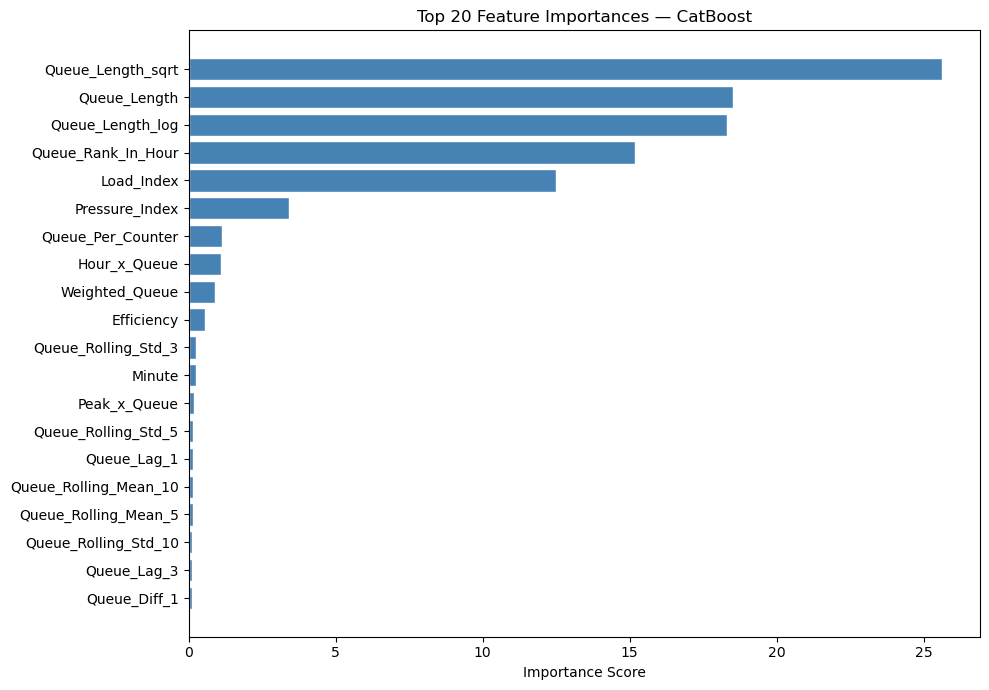

 Plot saved: feature_importance_catboost.png


In [29]:
plt.figure(figsize=(10, 7))
plt.barh(
    feat_imp['Feature'].head(20)[::-1],
    feat_imp['Importance'].head(20)[::-1],
    color='steelblue', edgecolor='white'
)
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances — CatBoost')
plt.tight_layout()
plt.savefig('feature_importance_catboost.png', dpi=150)
plt.show()
print(" Plot saved: feature_importance_catboost.png")


---
##  Section 15: SHAP Analysis

**SHAP (SHapley Additive exPlanations)** توضیح می‌دهد که هر ویژگی برای هر پیش‌بینی
چقدر و در چه جهتی تأثیر گذاشته است.

سه نمودار تولید می‌شود:

| نمودار | توضیح |
|---|---|
| **Summary Plot** | توزیع تأثیر هر ویژگی روی کل داده‌های تست |
| **Bar Plot** | میانگین قدرمطلق SHAP — رتبه‌بندی کلی اهمیت |
| **Waterfall Plot** | تفکیک پیش‌بینی یک نمونه خاص (اولین رکورد تست) |


Computing SHAP values (this may take ~1 min)...


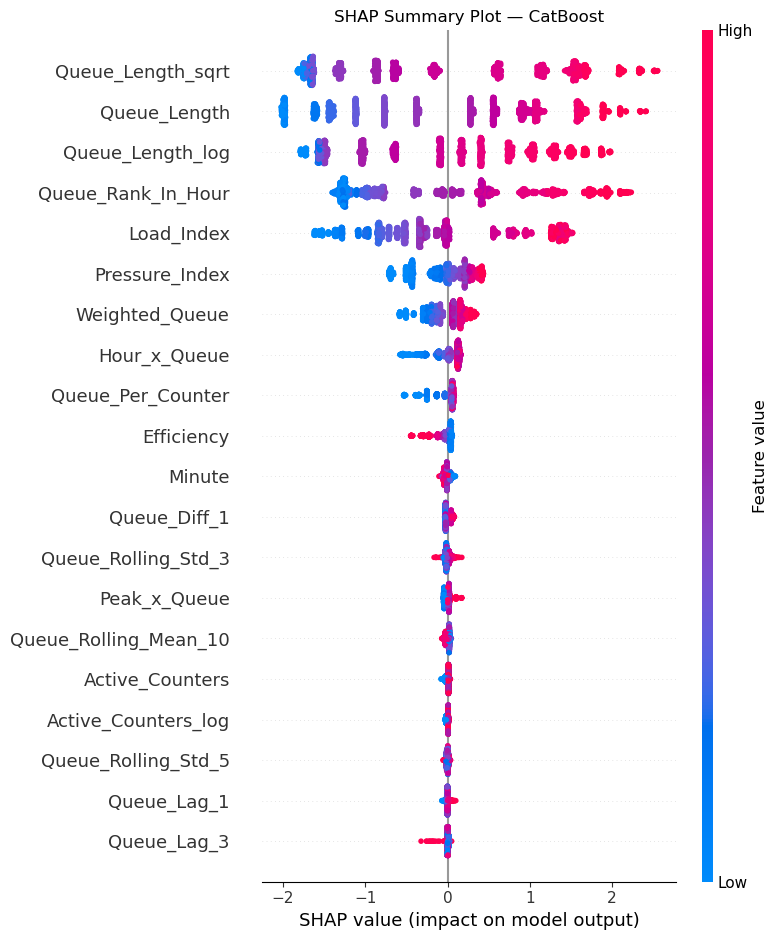

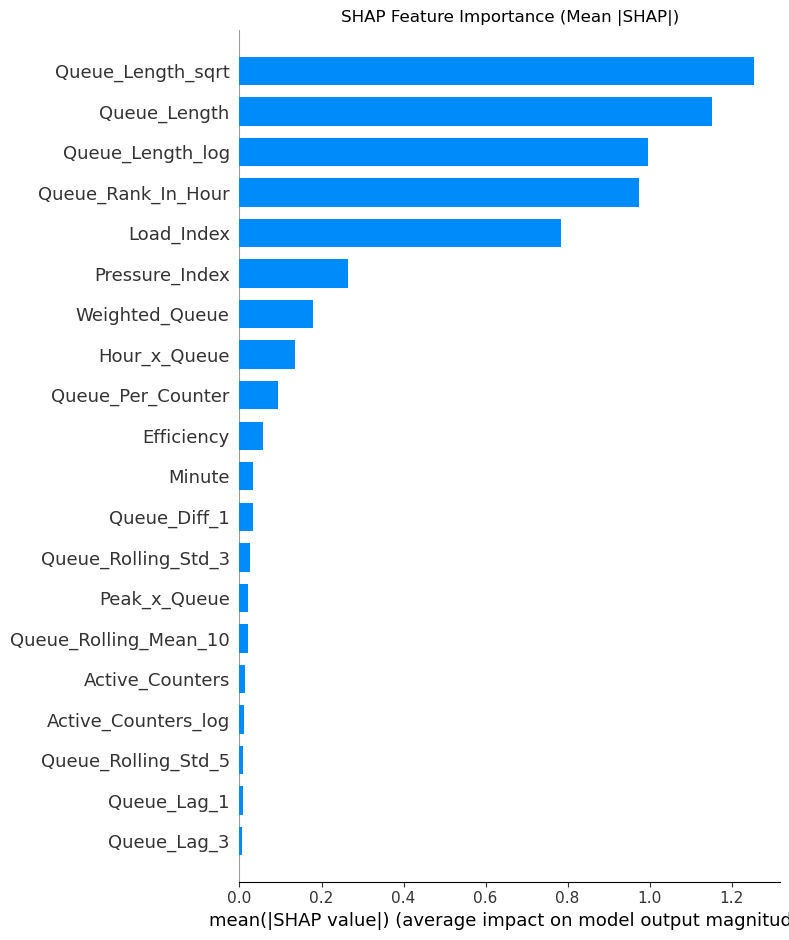

 SHAP plots saved: shap_summary.png, shap_bar.png


In [30]:
print("Computing SHAP values (this may take ~1 min)...")

explainer   = shap.TreeExplainer(best_cat)
shap_values = explainer.shap_values(X_test_sc_df)

# ── Summary plot ───────────────────────────────────────────────────────────────
shap.summary_plot(shap_values, X_test_sc_df, max_display=20, show=False)
plt.title('SHAP Summary Plot — CatBoost')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

# ── Bar plot ───────────────────────────────────────────────────────────────────
shap.summary_plot(shap_values, X_test_sc_df, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150)
plt.show()

print(" SHAP plots saved: shap_summary.png, shap_bar.png")



##  Section 16: SHAP Waterfall — Single Prediction Explanation

Waterfall plot نشان می‌دهد که برای **یک مشتری خاص**، هر ویژگی چقدر
پیش‌بینی را از مقدار پایه (میانگین کل) بالا یا پایین برده است.

-  قرمز: ویژگی پیش‌بینی را **افزایش** داده (انتظار بیشتر)
-  آبی: ویژگی پیش‌بینی را **کاهش** داده (انتظار کمتر)


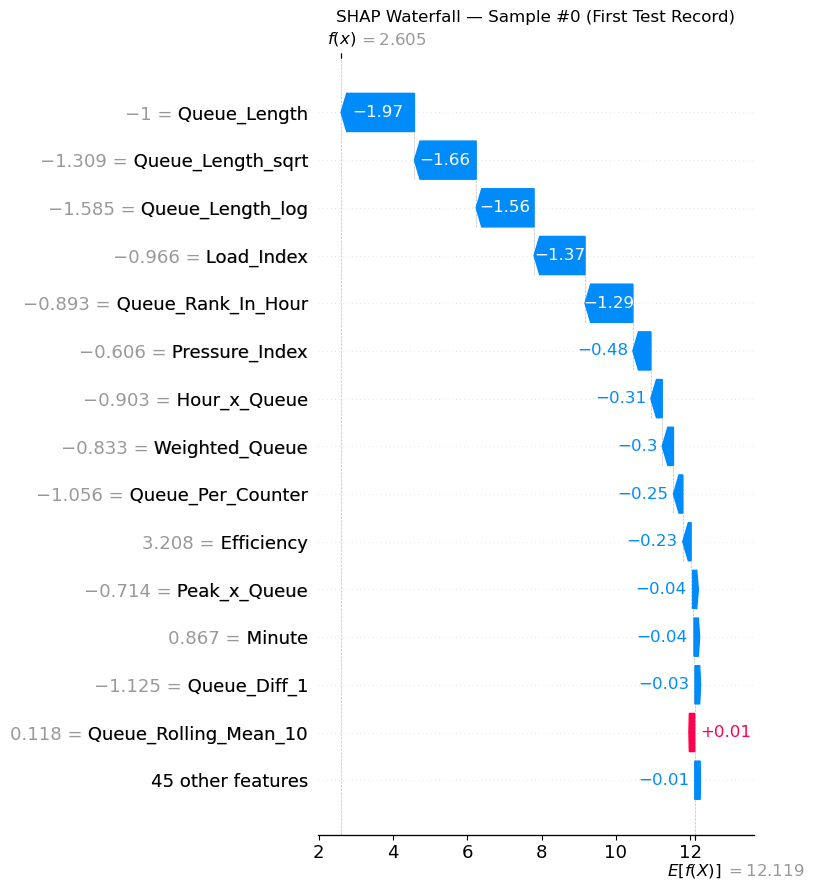

  Base value (mean prediction) : 12.1192 min
  Model prediction for sample 0: 2.6055 min
  Actual waiting time          : 0.0000 min
 Waterfall plot saved: shap_waterfall.png


In [31]:
# Waterfall for the first test sample
shap_explanation = shap.Explanation(
    values        = shap_values[0],
    base_values   = explainer.expected_value,
    data          = X_test_sc_df.iloc[0].values,
    feature_names = feature_cols
)

shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Sample #0 (First Test Record)')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150)
plt.show()

print(f"  Base value (mean prediction) : {explainer.expected_value:.4f} min")
print(f"  Model prediction for sample 0: {best_cat.predict(X_test_sc_df.iloc[[0]])[0]:.4f} min")
print(f"  Actual waiting time          : {y_test.iloc[0]:.4f} min")
print(" Waterfall plot saved: shap_waterfall.png")



##  Section 17: Actual vs Predicted Plot

نمودار پراکندگی مقادیر واقعی در برابر پیش‌بینی‌های مدل Stacking.
هر چه نقاط به خط قرمز (خط ایده‌آل $y = x$) نزدیک‌تر باشند، مدل دقیق‌تر است.


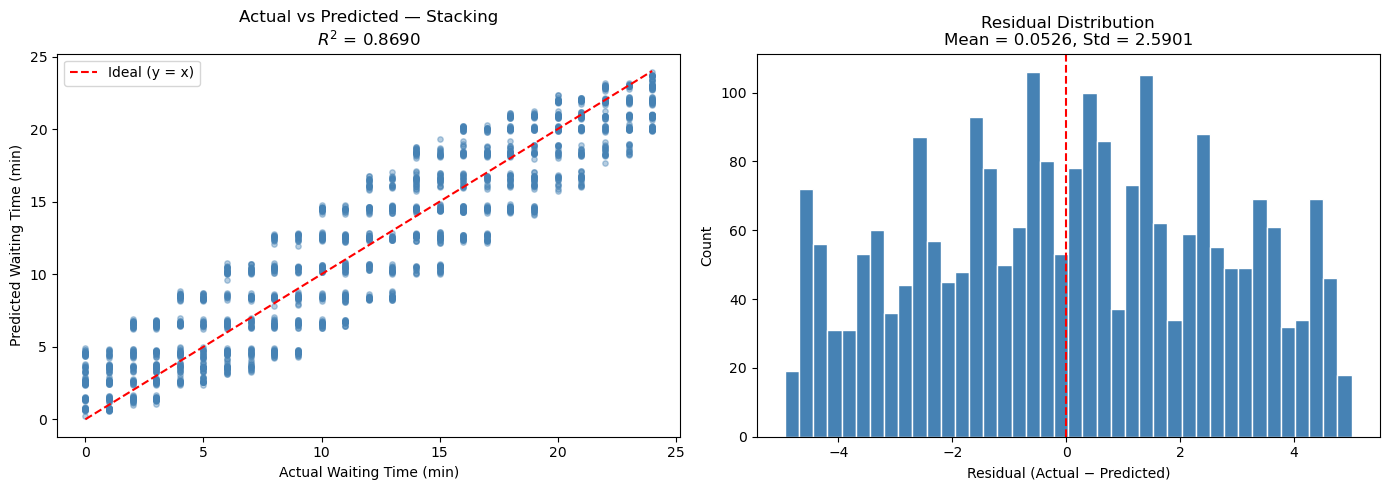

Plot saved: actual_vs_predicted.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter: Actual vs Predicted ───────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_stack_test, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred_stack_test.min()),
        max(y_test.max(), y_pred_stack_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y = x)')
axes[0].set_xlabel('Actual Waiting Time (min)')
axes[0].set_ylabel('Predicted Waiting Time (min)')
axes[0].set_title(f'Actual vs Predicted — Stacking\n$R^2$ = {stack_r2:.4f}')
axes[0].legend()

# ── Residual distribution ──────────────────────────────────────────────────────
residuals = y_test.values - y_pred_stack_test
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved: actual_vs_predicted.png")



##  Section 18: Final Results Summary

خلاصه نهایی عملکرد تمام مدل‌ها در یک جدول مقایسه‌ای.


In [34]:
# Add stacking to results dict
results['Stacking_Ensemble'] = {
    'Train_MAE': stack_train_mae,
    'Test_MAE':  stack_test_mae,
    'RMSE':      stack_rmse,
    'R2':        stack_r2,
    'Gap':       stack_test_mae - stack_train_mae,
}

summary_df = pd.DataFrame(results).T.round(4)
summary_df = summary_df.sort_values('Test_MAE')

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(summary_df.to_string())
print("\n" + "=" * 70)
print(f" Best model by Test MAE : {summary_df['Test_MAE'].idxmin()}")
print(f"   Test MAE  : {summary_df['Test_MAE'].min():.4f} min")
print(f"   R²        : {summary_df.loc[summary_df['Test_MAE'].idxmin(), 'R2']:.4f}")
print(f"   Gap       : {summary_df.loc[summary_df['Test_MAE'].idxmin(), 'Gap']:.4f} min")
print("=" * 70)


FINAL MODEL COMPARISON
                    Train_MAE  Test_MAE    RMSE      R2     Gap
Stacking_Ensemble      2.2026    2.1819  2.5906  0.8690 -0.0207
CatBoost_Optimized     2.1290    2.1857  2.5936  0.8687  0.0566
RandomForest           1.7505    2.2072  2.6278  0.8652  0.4567
GradientBoosting       1.7405    2.2286  2.6565  0.8622  0.4880
LightGBM               1.6898    2.2442  2.6720  0.8606  0.5545
XGBoost                1.5451    2.2586  2.6908  0.8587  0.7135

 Best model by Test MAE : Stacking_Ensemble
   Test MAE  : 2.1819 min
   R²        : 0.8690
   Gap       : -0.0207 min


---
## Section 19: Save Model & Artifacts

تمام خروجی‌های مدل ذخیره می‌شوند تا بدون نیاز به آموزش مجدد قابل استفاده باشند.

| فایل | محتوا |
|---|---|
| `stacking_model.pkl` | مدل Stacking کامل |
| `catboost_optimized.pkl` | مدل CatBoost بهینه‌شده |
| `scaler.pkl` | RobustScaler (برای داده‌های جدید) |
| `feature_cols.pkl` | لیست ویژگی‌های نهایی |
| `summary_results.csv` | جدول مقایسه مدل‌ها |


In [35]:
import pickle

artifacts = {
    'stacking_model.pkl':    stacking_model,
    'catboost_optimized.pkl': best_cat,
    'scaler.pkl':            scaler,
    'feature_cols.pkl':      feature_cols,
}

for filename, obj in artifacts.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f" Saved: {filename}")

summary_df.to_csv('summary_results.csv')
print(" Saved: summary_results.csv")

print("\n All artifacts saved successfully.")
print(f"   To reload: pickle.load(open('stacking_model.pkl', 'rb'))")


 Saved: stacking_model.pkl
 Saved: catboost_optimized.pkl
 Saved: scaler.pkl
 Saved: feature_cols.pkl
 Saved: summary_results.csv

 All artifacts saved successfully.
   To reload: pickle.load(open('stacking_model.pkl', 'rb'))
